# Breast Cancer Prediction using Logistic Regression

**Goal:** Predict whether a breast tumor is **Malignant (cancerous)** or **Benign (not cancerous)** using measurements taken from cell images.

**Dataset:** [Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data) from Kaggle, downloaded directly with `kagglehub`.

**Algorithm:** Logistic Regression (a classic, easy-to-understand model for yes/no problems).

### What you will learn in this notebook
1. Download a dataset from Kaggle using code
2. Explore and clean the data
3. Split the data and scale the features
4. Train a Logistic Regression model
5. Evaluate it with Accuracy, Precision, Recall, F1-score, Confusion Matrix, and ROC-AUC

## Step 1: Install and Import Libraries

Libraries are ready-made tools so we do not have to write everything from scratch:

- **kagglehub**: downloads datasets from Kaggle
- **pandas / numpy**: work with tables and numbers
- **matplotlib / seaborn**: draw charts
- **scikit-learn**: provides the machine learning tools

If `kagglehub` is not installed, uncomment and run the first line below.

In [1]:
# !pip install kagglehub pandas numpy matplotlib seaborn scikit-learn

import os
import warnings

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Download the Dataset from Kaggle

`kagglehub.dataset_download()` downloads the dataset to your computer and gives us the folder path where it is saved.
We do **not** type or paste any data by hand.

> Note: This is a public dataset, so no Kaggle login is normally needed. If Kaggle asks for credentials, see the README for instructions.

In [2]:
# Download the latest version of the dataset from Kaggle
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print("Dataset downloaded to:", path)

# See which files were downloaded
print("Files:", os.listdir(path))

100%|██████████| 48.6k/48.6k [00:00<00:00, 23.2MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/uciml/breast-cancer-wisconsin-data/versions/2
Files: ['data.csv']


## Step 3: Load the Dataset

The downloaded folder contains a CSV file called `data.csv`. We read it into a pandas **DataFrame** (think of it as an Excel sheet inside Python).

In [3]:
csv_path = os.path.join(path, "data.csv")
df = pd.read_csv(csv_path)

print("Shape of the dataset (rows, columns):", df.shape)
df.head()

Shape of the dataset (rows, columns): (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Step 4: Understand the Dataset

Before building any model, we should know what our data looks like.

- Each **row** is one patient's tumor sample.
- `diagnosis` is what we want to predict: **M** = Malignant, **B** = Benign.
- The other columns are measurements such as radius, texture, perimeter, and area. For each one the dataset gives the **mean**, **standard error (se)** and **worst** (largest) value.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
# Summary statistics (mean, min, max, etc.) for each numeric column
df.describe().T.head(12)

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.00000,869218.00000,906024.00000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.98100,11.70000,13.37000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.71000,16.17000,18.84000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.79000,75.17000,86.24000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.50000,420.30000,551.10000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.05263,0.08637,0.09587,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.01938,0.06492,0.09263,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.00000,0.02956,0.06154,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.00000,0.02031,0.03350,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.10600,0.16190,0.17920,1.957000e-01,3.040000e-01


### How balanced are the two classes?

If one class is much bigger than the other, the model can become biased towards it. Let's check.

diagnosis
B    357
M    212
Name: count, dtype: int64

diagnosis
B    62.7 %
M    37.3 %
Name: count, dtype: object


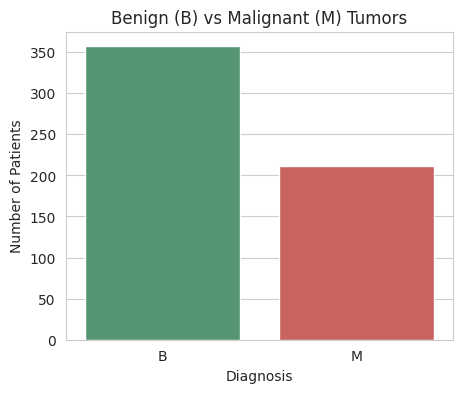

In [6]:
counts = df["diagnosis"].value_counts()
print(counts)
print()
print((counts / len(df) * 100).round(1).astype(str) + " %")

plt.figure(figsize=(5, 4))
sns.countplot(x="diagnosis", data=df, palette=["#4C9F70", "#D9534F"], order=["B", "M"])
plt.title("Benign (B) vs Malignant (M) Tumors")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")
plt.show()

## Step 5: Data Cleaning and Checking Missing Values

Real-world data is rarely perfect. We check for:

1. **Missing values** (empty cells)
2. **Useless columns** (columns that carry no information for prediction)
3. **Duplicate rows**

In [7]:
# Count missing values in each column (show only columns that have any)
missing = df.isnull().sum()
print(missing[missing > 0])

Unnamed: 32    569
dtype: int64


We can see that the column **`Unnamed: 32`** is completely empty (it appears because of a trailing comma in the CSV file). The **`id`** column is just a patient number and does not help predict cancer.
We will drop both columns.

In [8]:
# Drop the empty column and the ID column
df = df.drop(columns=["Unnamed: 32", "id"], errors="ignore")

# Check again: there should be no missing values now
print("Total missing values after cleaning:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("New shape:", df.shape)

Total missing values after cleaning: 0
Duplicate rows: 0
New shape: (569, 31)


## Step 6: Encode the Target Column

Machine learning models work with numbers, not letters. We convert the `diagnosis` column:

- **M (Malignant)** becomes **1**
- **B (Benign)** becomes **0**

Here, `1` is our "positive" class, the one we most want to detect.

In [9]:
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})
df["diagnosis"].value_counts()

,count
diagnosis,
0,357
1,212


## Step 7: Quick Visual Exploration

A correlation heatmap shows how strongly each feature is related to the diagnosis. Features with a high correlation are usually more useful for prediction.

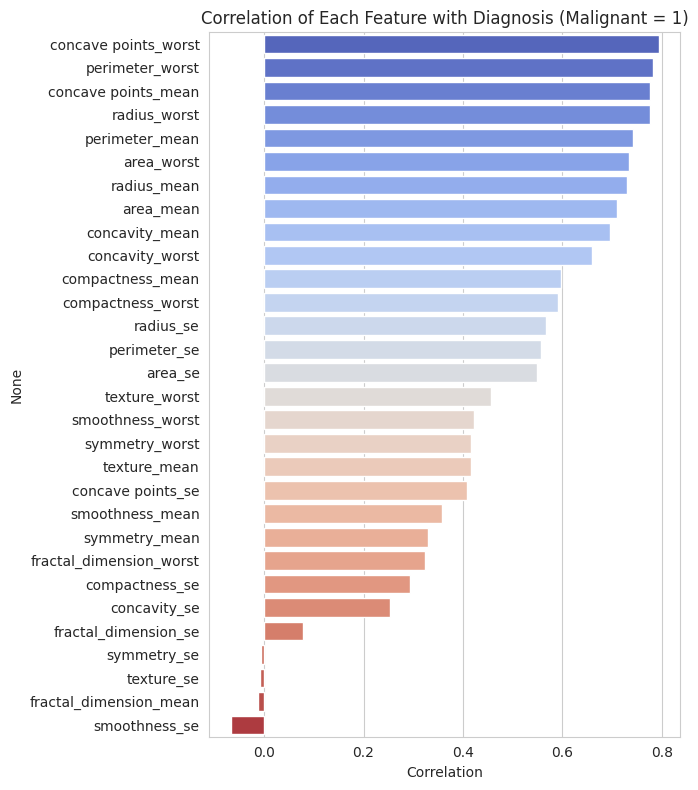

In [10]:
correlations = df.corr()["diagnosis"].drop("diagnosis").sort_values(ascending=False)

plt.figure(figsize=(7, 8))
sns.barplot(x=correlations.values, y=correlations.index, palette="coolwarm")
plt.title("Correlation of Each Feature with Diagnosis (Malignant = 1)")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

## Step 8: Select Features (X) and Target (y)

- **X (features)**: all the measurements used to make a prediction
- **y (target)**: the answer we want to predict (`diagnosis`)

In [11]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("Features shape:", X.shape)
print("Target shape:  ", y.shape)

Features shape: (569, 30)
Target shape:   (569,)


## Step 9: Train-Test Split

We divide the data into two parts:

- **Training set (80%)**: the model learns from this
- **Test set (20%)**: used only at the end to check how well the model works on **new, unseen** data

We use `stratify=y` so both sets keep the same Benign/Malignant ratio, and `random_state=42` so the results are repeatable.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples: 455
Testing samples:  114


## Step 10: Feature Scaling with StandardScaler

The features are on very different scales (for example, `area_mean` is in the hundreds while `smoothness_mean` is below 1).
Logistic Regression trains better when all features are on a similar scale.

`StandardScaler` converts every feature so that it has a **mean of 0** and a **standard deviation of 1**.

**Important rule:** we `fit` the scaler on the **training data only**, then use it to `transform` both sets. Fitting on the test data would leak information and make our results look better than they really are.

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # learn from training data and transform it
X_test_scaled = scaler.transform(X_test)        # only transform the test data

print("Mean of first 3 scaled training features:", X_train_scaled[:, :3].mean(axis=0).round(2))
print("Std of first 3 scaled training features: ", X_train_scaled[:, :3].std(axis=0).round(2))

Mean of first 3 scaled training features: [-0.  0.  0.]
Std of first 3 scaled training features:  [1. 1. 1.]


## Step 11: Train the Logistic Regression Model

**How does Logistic Regression work?**
Despite its name, it is used for **classification**. It calculates a score from the features and passes it through the *sigmoid function*, which squeezes the score into a **probability between 0 and 1**.

- Probability **≥ 0.5** → predict **Malignant (1)**
- Probability **< 0.5** → predict **Benign (0)**

Calling `.fit()` is where the model learns from the training data.

In [14]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


## Step 12: Make Predictions

We ask the trained model to predict on the test set, which it has never seen before.

- `predict()` gives the final class (0 or 1)
- `predict_proba()` gives the probability of each class. We need the probability of Malignant for the ROC curve.

In [15]:
y_pred = model.predict(X_test_scaled)                # predicted classes (0 or 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]    # probability of being Malignant

comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10],
    "Probability of Malignant": y_prob[:10].round(3),
})
comparison

,Actual,Predicted,Probability of Malignant
0,0,0,0.000
1,1,1,1.000
2,0,0,0.043
3,1,1,0.576
4,0,1,0.509
5,0,0,0.001
6,1,1,0.762
7,0,0,0.001
8,0,0,0.001
9,0,0,0.011


## Step 13: Evaluate the Model

### 13.1 Accuracy, Precision, Recall, F1-score and ROC-AUC

| Metric | Simple meaning |
|---|---|
| **Accuracy** | Out of all predictions, how many were correct? |
| **Precision** | When the model says "Malignant", how often is it right? |
| **Recall** | Out of all truly Malignant tumors, how many did the model find? |
| **F1-score** | A balance between Precision and Recall |
| **ROC-AUC** | How well the model separates the two classes (1.0 is perfect, 0.5 is random guessing) |

In cancer detection, **Recall is especially important**, because missing a real cancer case (a false negative) is very costly.

In [16]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc],
}).round(4)
results

,Metric,Score
0,Accuracy,0.9649
1,Precision,0.9750
2,Recall,0.9286
3,F1-score,0.9512
4,ROC-AUC,0.9960


### 13.2 Confusion Matrix

A confusion matrix shows exactly where the model was right and wrong:

- **True Negative (TN):** Benign correctly predicted as Benign
- **False Positive (FP):** Benign wrongly predicted as Malignant
- **False Negative (FN):** Malignant wrongly predicted as Benign (the most dangerous mistake)
- **True Positive (TP):** Malignant correctly predicted as Malignant

In [17]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

Confusion Matrix:
[[71  1]
 [ 3 39]]

True Negatives : 71
False Positives: 1
False Negatives: 3
True Positives : 39


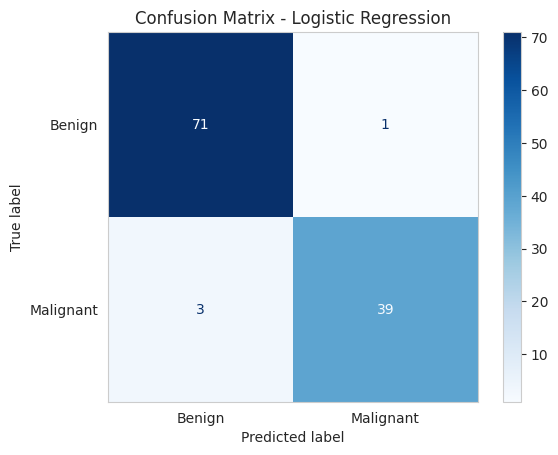

In [18]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.grid(False)
plt.show()

### 13.3 Classification Report

This report shows Precision, Recall and F1-score for **each** class in one table.

In [19]:
print(classification_report(y_test, y_pred, target_names=["Benign", "Malignant"]))

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



### 13.4 ROC Curve and ROC-AUC

The **ROC curve** plots the True Positive Rate against the False Positive Rate at every possible probability threshold.
The closer the curve hugs the **top-left corner**, the better the model. The dashed diagonal line represents random guessing.
The **AUC** (area under the curve) summarizes the curve in one number.

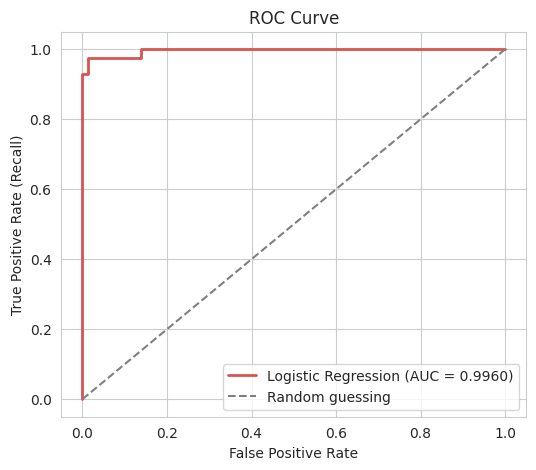

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#D9534F", lw=2, label=f"Logistic Regression (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guessing")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

## Step 14: Which Features Matter Most?

One big advantage of Logistic Regression is that it is **easy to interpret**. Each feature has a *coefficient*:

- **Positive coefficient** → higher values push the prediction towards **Malignant**
- **Negative coefficient** → higher values push the prediction towards **Benign**

Because we scaled the features, the coefficients can be compared fairly with each other.

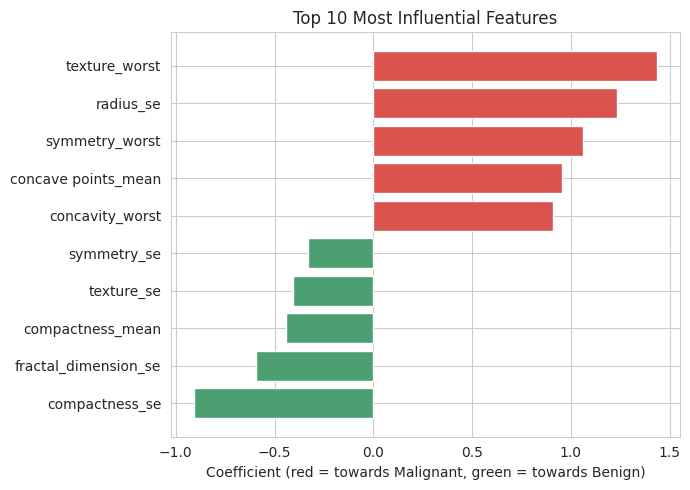

In [21]:
coefficients = pd.Series(model.coef_[0], index=X.columns).sort_values()
top = pd.concat([coefficients.head(5), coefficients.tail(5)])

plt.figure(figsize=(7, 5))
colors = ["#4C9F70" if c < 0 else "#D9534F" for c in top.values]
plt.barh(top.index, top.values, color=colors)
plt.title("Top 10 Most Influential Features")
plt.xlabel("Coefficient (red = towards Malignant, green = towards Benign)")
plt.tight_layout()
plt.show()

## Conclusion

- We downloaded the **Breast Cancer Wisconsin (Diagnostic)** dataset directly from Kaggle using `kagglehub`.
- We cleaned the data by removing an empty column and the useless `id` column, and encoded the target (M = 1, B = 0).
- We split the data into training and test sets and scaled the features with `StandardScaler`.
- A **Logistic Regression** model reached very high scores on the unseen test data (see the metric table above for the exact numbers).
- The confusion matrix shows the model makes only a few mistakes, and the ROC-AUC score shows it separates Benign and Malignant tumors very well.

### Things to try next
- Compare with other models (Random Forest, SVM, KNN)
- Use cross-validation for a more reliable estimate
- Tune hyperparameters such as `C` with `GridSearchCV`
- Lower the decision threshold to push Recall even higher

> **Disclaimer:** This project is for learning purposes only. It is not a medical tool and must not be used for real diagnosis.